In [ ]:
%pip install ucimlrepo

ValueError: not enough values to unpack (expected at least 1, got 0)

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV,  StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc


from ucimlrepo import fetch_ucirepo 

Question: Can we predict a wines quality?
So therfeore the target varible is wine quality and the indpendet varible is all the other varibels (11) 

PART ONE: LOAD DATA 

In [ ]:
## Import data set 
df1 = pd.read_csv(r"C:\Users\damia\OneDrive\Desktop\DTSC 2301 Folder\DTSC Project 2\winequality-white.csv", sep=";")
df2=pd.read_csv(r"C:\Users\damia\OneDrive\Desktop\DTSC 2301 Folder\DTSC Project 2\winequality-red.csv", sep=";")

In [ ]:
df=pd.concat([df1,df2])

PART TWO: CLEAN DATA

In [ ]:
df.shape

(6497, 12)

In [ ]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
len(df.columns)

12

In [ ]:
## CHECK FOR OUTLIERS
def find_outliers(col_name, df):
    # This function identifies the number of outliers in a given column using the Tukey Definition
    # Calculate IQR
    q1=np.percentile(df[col_name], 25)
    q3=np.percentile(df[col_name], 75)
    iqr=q3-q1

    # Calculate Threshold and bounds
    threshold=1.5*iqr
    
    lb=q1-threshold
    ub=q3+threshold

    # Identify outliers
    outliers = np.where((df[col_name] < lb) | (df[col_name] > ub))

    return len(outliers)

In [ ]:
## note there are no outliers 

In [ ]:
import numpy as np

# COUNT OUTLIERS IN EACH COLOUMN
for c in df.select_dtypes(include=[np.number]).columns:
    num_outliers=find_outliers(c,df)
    print(c ,": ",  num_outliers)


fixed acidity :  1
volatile acidity :  1
citric acid :  1
residual sugar :  1
chlorides :  1
free sulfur dioxide :  1
total sulfur dioxide :  1
density :  1
pH :  1
sulphates :  1
alcohol :  1
quality :  1


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
df["rating_cat"]= df["quality"].map({
    1:"poor",
    2:"poor",
    3:"poor",
    4:"decent",
    5:"decent",
    6:"decent",
    7:"good",
    8:"good",
    9:"good",
    10:"good"
})
## Changing the qulaity rating and adding it to another column essentially compressing it to 3 diffrent groups. 

PART THREE: EXPLORATORY DATA ANYALSIS

In [ ]:
X=df.drop(columns=["quality","rating_cat"],axis=1)
y=df["rating_cat"]
## Setting my X and Y vaules 


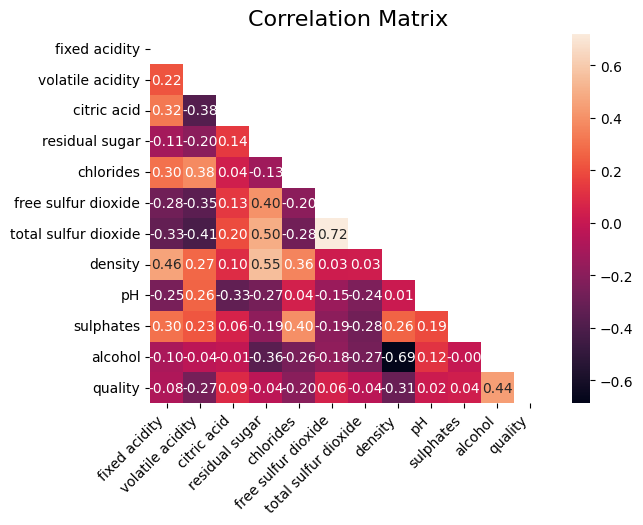

In [ ]:
# create a coorleation matrix showing the reltionship between continius varibles 
# Create a Correlation Matrix showing relationship between continuous variables
corr_mat=df.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt=".2f", mask=mask)
plt.xticks(rotation=45, ha='right')   # Tilt labels for better fit
plt.title("Correlation Matrix", fontsize=16)
plt.show()

PART FOUR:FEATURE ENGINEERIGN AND PREPROCESSING

Tranning my data spliting it 80 20 and using the folding so each gorup gets tested equally 

In [ ]:
import sklearn
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.8, random_state=42
)

In [ ]:
## tranning and testing the X and Y

In [ ]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (5197, 11)
X_test (1300, 11)
y_train (5197,)
y_test (1300,)


PART FIVE: MODELS

In [ ]:

# Initialize Cross-Validation Rules
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
## Baseline Linear Regression Model... teling me how Low the other models can go

from sklearn.linear_model import LogisticRegression

# Define Hyperparameter Grid
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "max_iter": [100, 200, 500]
}

lr_model = LogisticRegression(solver="lbfgs", random_state=42)

grid_search_lr = GridSearchCV(
    estimator=lr_model, param_grid=param_grid_lr, cv=skf, scoring="roc_auc_ovr_weighted"
)

grid_search_lr.fit(X_train_scaled, y_train)

lr_best_params = grid_search_lr.best_params_
lr_best_score = grid_search_lr.best_score_

print(f"Best Parameters: {lr_best_params}")
print(f"Best Cross-Validation ROC AUC Score: {lr_best_score:.4f}")


Best Parameters: {'C': 10, 'max_iter': 100}
Best Cross-Validation ROC AUC Score: 0.8001


In [ ]:
# Method 1: Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Define Hyperparameter Grid
param_grid_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_model = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_model, param_grid=param_grid_dt, cv=skf, scoring="roc_auc_ovr_weighted"
)

grid_search_dt.fit(X_train, y_train)

dt_best_params = grid_search_dt.best_params_
dt_best_score = grid_search_dt.best_score_

print(f"Best Parameters: {dt_best_params}")
print(f"Best Cross-Validation ROC AUC Score: {dt_best_score:.4f}")

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation ROC AUC Score: 0.8094


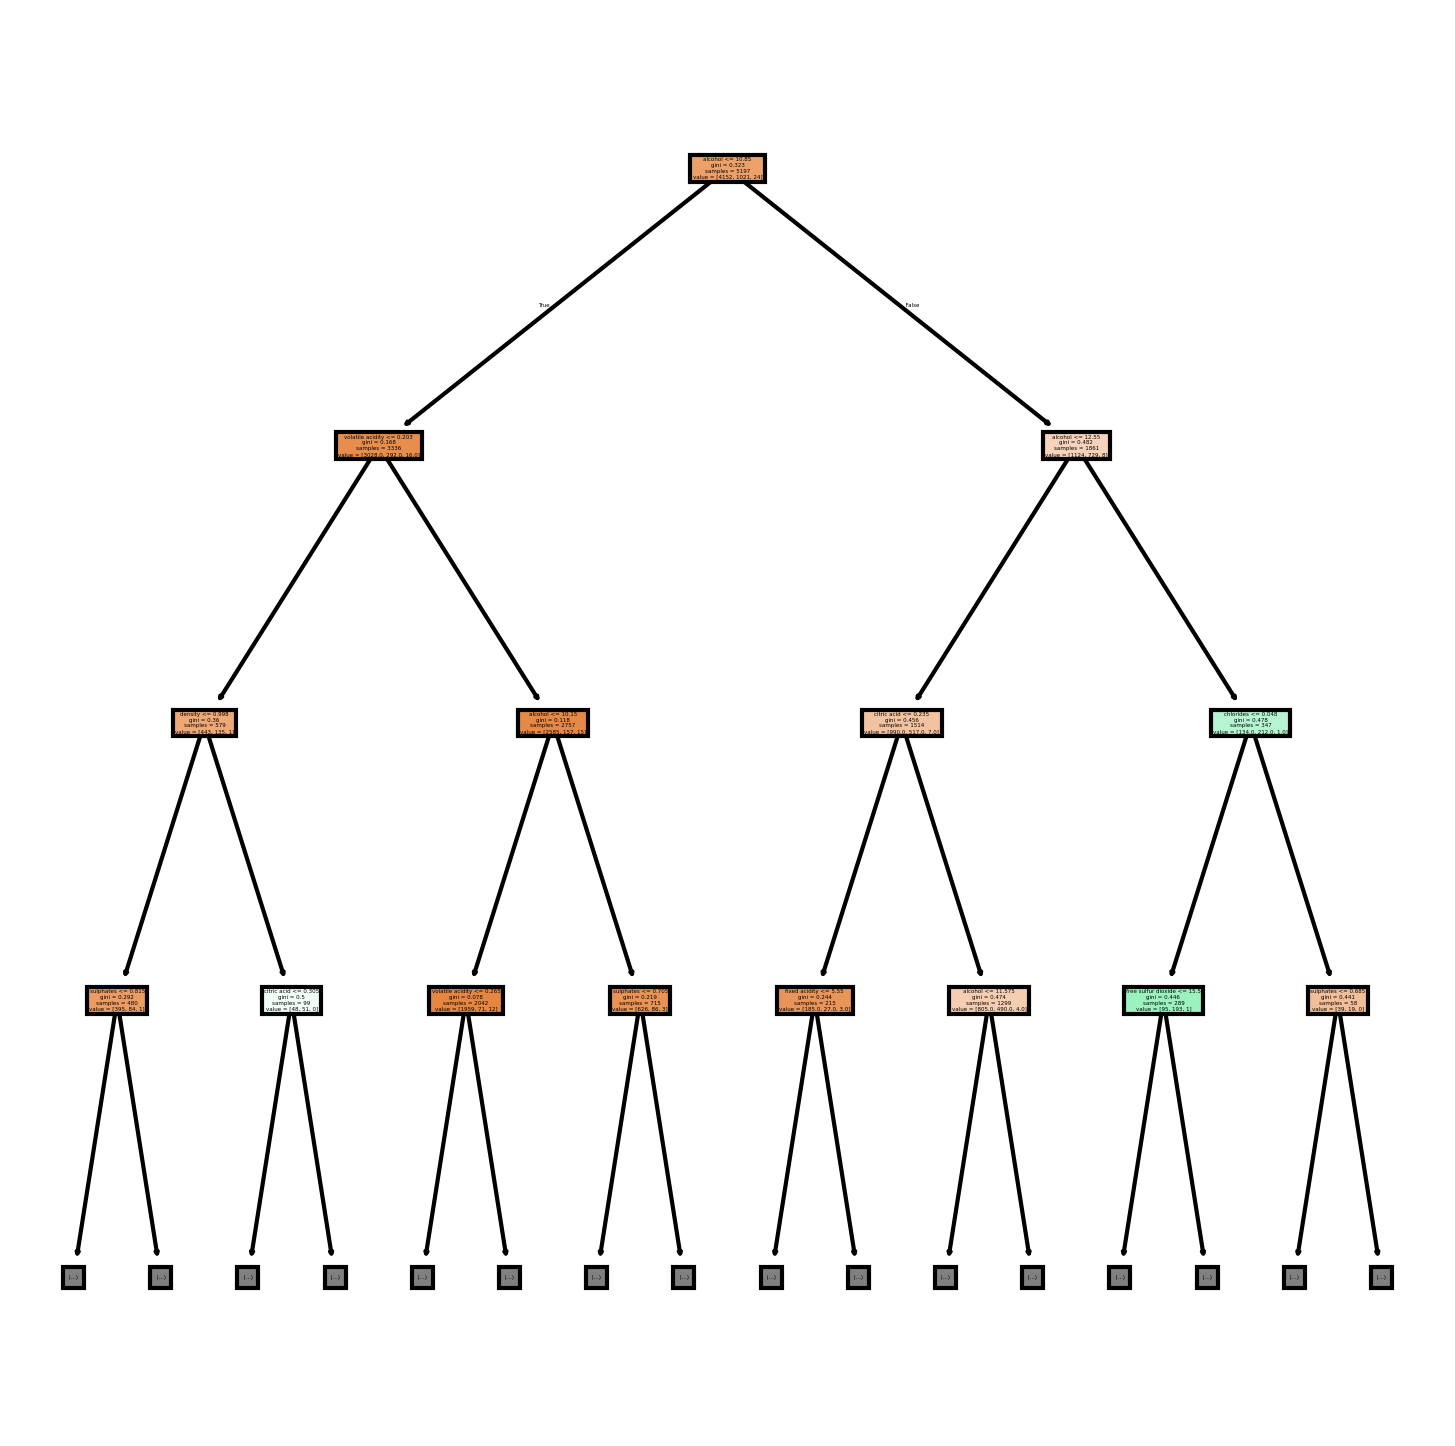

In [ ]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=300)
plot_tree(grid_search_dt.best_estimator_, max_depth=3, feature_names=X.columns, filled=True, ax=axes)
plt.show()

In [ ]:
# Method 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Define Hyperparameter Grid
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_model, param_grid=param_grid_rf, cv=skf, scoring="roc_auc_ovr_weighted"
)

grid_search_rf.fit(X_train, y_train)

rf_best_params = grid_search_rf.best_params_
rf_best_score = grid_search_rf.best_score_

print(f"Best Parameters: {rf_best_params}")
print(f"Best Cross-Validation ROC AUC Score: {rf_best_score:.4f}")

KeyboardInterrupt: 

In [ ]:
%pip install xgboost

# Method 3: XGBoost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels, so encode rating_cat
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Define Hyperparameter Grid
param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")

grid_search_xgb = GridSearchCV(
    estimator=xgb_model, param_grid=param_grid_xgb, cv=skf, scoring="roc_auc_ovr_weighted"
)

grid_search_xgb.fit(X_train, y_train_enc)

xgb_best_params = grid_search_xgb.best_params_
xgb_best_score = grid_search_xgb.best_score_

print(f"Best Parameters: {xgb_best_params}")
print(f"Best Cross-Validation ROC AUC Score: {xgb_best_score:.4f}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}
Best Cross-Validation ROC AUC Score: 0.8942


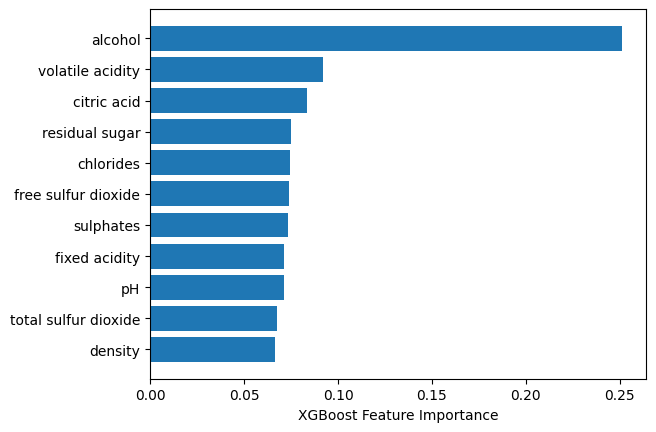

In [ ]:
# plot feature importance of XGBoost
sorted_idx = grid_search_xgb.best_estimator_.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], grid_search_xgb.best_estimator_.feature_importances_[sorted_idx])
plt.xlabel("XGBoost Feature Importance")
plt.show()

In [ ]:
y_pred = grid_search_rf.best_estimator_.predict(X_test)

<Axes: >

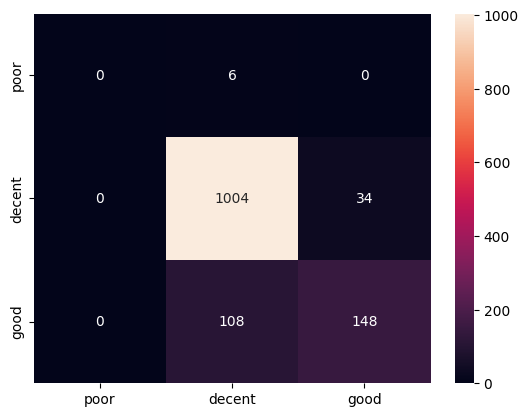

In [ ]:
## Confusion Matrix for Random Forest 

wine_labels=["poor", "decent", "good"]
cm=confusion_matrix(y_test, y_pred,labels= wine_labels)
sns.heatmap(cm, annot=True,fmt='d', xticklabels=wine_labels,
            yticklabels=wine_labels)